# 🩸 Glucose ML Pipeline — Pandas + sklearn + XGBoost
### Comparação de Modelos | Seleção Automática pelo Melhor

| Bloco | Conteúdo |
|-------|----------|
| 1 | Instalação |
| 2 | Imports, Logging e Constantes |
| 3 | `GlucoseDataLoader` — Ingestão e validação |
| 4 | `FeatureEngineer` — Pré-processamento e correlação |
| 5 | `RegressionComparator` — GBT vs XGBoost vs RandomForest |
| 6 | `ClassificationComparator` — RF vs XGBoost vs Logística |
| 7 | `ModelVisualizer` — Visualizações e Dashboard |
| 8 | ▶ Execução Completa |


## 📦 Bloco 1 — Instalação

In [17]:
# %pip install pandas numpy scikit-learn xgboost matplotlib seaborn
print("✅ Dependências OK")


✅ Dependências OK


## 📥 Bloco 2 — Imports, Logging e Constantes

In [18]:
import logging, sys, warnings
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.ensemble import GradientBoostingRegressor, RandomForestClassifier, RandomForestRegressor
from sklearn.exceptions import NotFittedError
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    f1_score, mean_absolute_error, mean_squared_error, r2_score,
    roc_auc_score, roc_curve,
)
from sklearn.model_selection import (
    RandomizedSearchCV, StratifiedKFold,
    cross_val_score, train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelBinarizer, LabelEncoder, StandardScaler
from xgboost import XGBClassifier, XGBRegressor

warnings.filterwarnings("ignore")

# ── Logging ───────────────────────────────────────────────────────────────────
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)-8s | %(name)s | %(message)s",
    datefmt="%Y-%m-%d %H:%M:%S",
    handlers=[logging.StreamHandler(sys.stdout),
              logging.FileHandler("glucose_pipeline.log", encoding="utf-8")],
)

# ── Constantes ────────────────────────────────────────────────────────────────
RANDOM_STATE = 42
TEST_SIZE    = 0.2
CV_FOLDS     = 5
FIGURE_DPI   = 130

GLUCOSE_NORMAL_THRESHOLD   = 100.0
GLUCOSE_ELEVATED_THRESHOLD = 126.0
CLASS_LABELS               = ["alto", "elevado", "normal"]

PALETTE      = {"normal": "#4CAF50", "elevado": "#FF9800", "alto": "#F44336"}
DARK_BG      = "#1a1d27"
PANEL_BG     = "#12151e"
TEXT_COL     = "#e8e8e8"
GRID_COL     = "#2a2d3a"
MODEL_COLORS = {
    "GBT":                "#42A5F5",
    "XGBoost":            "#AB47BC",
    "RandomForest":       "#26A69A",
    "LogisticRegression": "#FF7043",
}

PATH_CSV = Path("Teste_ML_balanceado.csv")   # ← ajuste conforme necessário
print("✅ Imports e constantes carregados.")


✅ Imports e constantes carregados.


## 📂 Bloco 3 — `GlucoseDataLoader`

In [19]:
class GlucoseDataLoader:
    """Carrega, sanitiza e valida o CSV."""

    def __init__(self, filepath: str | Path, delimiter: str = ";"):
        self.filepath  = Path(filepath)
        self.delimiter = delimiter
        self.log       = logging.getLogger(self.__class__.__name__)

    def load(self) -> pd.DataFrame:
        self.log.info("Carregando: %s", self.filepath)
        if not self.filepath.exists():
            raise FileNotFoundError(f"Arquivo não encontrado: {self.filepath}")

        df = pd.read_csv(self.filepath, sep=self.delimiter)
        df = self._sanitize_columns(df)
        self._validate(df)
        self._report_missing(df)
        self.log.info("Shape: %s | Colunas: %s", df.shape, list(df.columns))
        return df

    def _sanitize_columns(self, df):
        import re
        df.columns = (df.columns.str.strip().str.lower()
                      .str.replace(r"\s+", "_", regex=True)
                      .str.replace(r"[^\w]", "", regex=True))
        return df

    def _validate(self, df):
        if df.empty:
            raise ValueError("DataFrame vazio.")
        if len(df) < 50:
            self.log.warning("Apenas %d linhas — resultados instáveis.", len(df))

    def _report_missing(self, df):
        m = df.isnull().sum(); m = m[m > 0]
        if m.empty: self.log.info("Sem valores ausentes.")
        else:       self.log.warning("Ausentes:\n%s", m.to_string())

print("✅ GlucoseDataLoader definido.")


✅ GlucoseDataLoader definido.


## 🔧 Bloco 4 — `FeatureEngineer`

In [20]:
class FeatureEngineer:
    """
    Pré-processa o DataFrame:
      • Codifica categóricas (cat.codes para as explícitas, LabelEncoder/get_dummies para o resto)
      • Remove colunas de drop
      • Alerta sobre multicolinearidade
      • Gera heatmap de correlação
    """

    def __init__(self, corr_threshold=0.85, drop_cols=None, cat_cols=None):
        self.corr_threshold = corr_threshold
        self.drop_cols      = drop_cols or []
        self.cat_cols       = cat_cols  or []
        self.log            = logging.getLogger(self.__class__.__name__)
        self._label_encoders = {}

    def fit_transform(self, df: pd.DataFrame, target_col: str):
        """Retorna (X, y) prontos para treino."""
        df = df.copy().dropna()

        for col in self.cat_cols:
            if col in df.columns:
                df[col] = df[col].astype("category").cat.codes

        obj_cols = [c for c in df.select_dtypes(include=["object","category"]).columns
                    if c != target_col and c not in self.drop_cols]
        binary = [c for c in obj_cols if df[c].nunique() <= 2]
        multi  = [c for c in obj_cols if df[c].nunique() > 2]

        for col in binary:
            le = LabelEncoder()
            df[col] = le.fit_transform(df[col].astype(str))
            self._label_encoders[col] = le

        if multi:
            df = pd.get_dummies(df, columns=multi, drop_first=True)

        cols_drop = [c for c in self.drop_cols if c in df.columns]
        df = df.drop(columns=cols_drop)

        y = df[target_col].copy()
        X = df.drop(columns=[target_col])

        self.log.info("Features (%d): %s", len(X.columns), list(X.columns))
        self._check_multicollinearity(X)
        return X, y

    def _check_multicollinearity(self, X):
        corr  = X.select_dtypes(include=[np.number]).corr().abs()
        upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
        high  = [(c, r, upper.loc[r,c]) for c in upper.columns for r in upper.index
                 if pd.notna(upper.loc[r,c]) and upper.loc[r,c] >= self.corr_threshold]
        if high:
            self.log.warning("⚠ Multicolinearidade (|r| ≥ %.2f):", self.corr_threshold)
            for a,b,v in sorted(high, key=lambda x: -x[2]):
                self.log.warning("  '%s' ↔ '%s' → r=%.4f", a, b, v)
        else:
            self.log.info("Sem multicolinearidade acima de %.2f.", self.corr_threshold)

    def plot_correlation_heatmap(self, X, y, figsize=(13,9)):
        data = X.copy(); data["glicose"] = y.values
        corr = data.select_dtypes(include=[np.number]).corr()
        mask = np.triu(np.ones_like(corr, dtype=bool))

        fig, ax = plt.subplots(figsize=figsize, dpi=FIGURE_DPI)
        fig.patch.set_facecolor(DARK_BG); ax.set_facecolor(DARK_BG)
        sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdYlGn",
                    center=0, linewidths=0.4, ax=ax, annot_kws={"size":8})
        ax.set_title("Correlação de Pearson — Features + Glicose",
                     color=TEXT_COL, fontsize=13, pad=12)
        ax.tick_params(colors=TEXT_COL, labelsize=8)
        plt.tight_layout()
        plt.savefig("heatmap_correlacao.png", dpi=FIGURE_DPI, bbox_inches="tight", facecolor=DARK_BG)
        plt.show()

print("✅ FeatureEngineer definido.")


✅ FeatureEngineer definido.


## 📈 Bloco 5 — `RegressionComparator`
> Treina e compara **GBT · XGBoost · RandomForest** com `RandomizedSearchCV`. Seleciona o melhor por **R²**.


In [21]:
class RegressionComparator:
    """
    Compara 3 regressores para predição do nível de glicose (mg/dL).
    Seleciona automaticamente o melhor por R².

    Modelos:
      • GradientBoostingRegressor (GBT)
      • XGBRegressor              (XGBoost)
      • RandomForestRegressor     (Random Forest)
    """

    MODELS = {
        "GBT":          GradientBoostingRegressor(random_state=RANDOM_STATE),
        "XGBoost":      XGBRegressor(random_state=RANDOM_STATE, verbosity=0,
                                     eval_metric="rmse", tree_method="hist"),
        "RandomForest": RandomForestRegressor(random_state=RANDOM_STATE),
    }

    PARAM_GRIDS = {
        "GBT": {
            "regressor__n_estimators":  [100, 200, 300],
            "regressor__learning_rate": [0.05, 0.1, 0.2],
            "regressor__max_depth":     [3, 4, 5],
            "regressor__subsample":     [0.8, 1.0],
        },
        "XGBoost": {
            "regressor__n_estimators":     [100, 200, 300],
            "regressor__learning_rate":    [0.05, 0.1, 0.2],
            "regressor__max_depth":        [3, 4, 6],
            "regressor__subsample":        [0.8, 1.0],
            "regressor__colsample_bytree": [0.7, 1.0],
        },
        "RandomForest": {
            "regressor__n_estimators":     [100, 200, 300],
            "regressor__max_depth":        [None, 5, 10, 20],
            "regressor__min_samples_leaf": [1, 2, 4],
        },
    }

    def __init__(self, n_iter: int = 15):
        self.n_iter    = n_iter
        self.log       = logging.getLogger(self.__class__.__name__)
        self.results_  = {}
        self.best_name_= ""
        self.best_pipe_= None
        self.X_test_   = None
        self.y_test_   = None

    def fit(self, X: pd.DataFrame, y: pd.Series) -> "RegressionComparator":
        """Treina todos os modelos com HPO e armazena resultados."""
        X_train, self.X_test_, y_train, self.y_test_ = train_test_split(
            X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
        )
        self.log.info("Split: %d treino | %d teste", len(X_train), len(self.X_test_))

        for name, estimator in self.MODELS.items():
            self.log.info("─── Treinando Regressão: %s ───", name)
            pipe = Pipeline([("scaler", StandardScaler()), ("regressor", estimator)])

            search = RandomizedSearchCV(
                pipe, param_distributions=self.PARAM_GRIDS[name],
                n_iter=self.n_iter, cv=CV_FOLDS, scoring="r2",
                n_jobs=-1, random_state=RANDOM_STATE, verbose=0,
            )
            search.fit(X_train, y_train)

            best_pipe = search.best_estimator_
            y_pred    = best_pipe.predict(self.X_test_)
            rmse      = np.sqrt(mean_squared_error(self.y_test_, y_pred))
            mae       = mean_absolute_error(self.y_test_, y_pred)
            r2        = r2_score(self.y_test_, y_pred)
            cv_r2     = cross_val_score(best_pipe, X_train, y_train, cv=CV_FOLDS, scoring="r2")

            self.results_[name] = {
                "pipeline": best_pipe, "best_params": search.best_params_,
                "y_pred": y_pred,
                "R²": round(r2,4), "RMSE": round(rmse,4), "MAE": round(mae,4),
                "CV R² Mean": round(cv_r2.mean(),4), "CV R² Std": round(cv_r2.std(),4),
            }
            self.log.info("%s → R²=%.4f | RMSE=%.4f | MAE=%.4f", name, r2, rmse, mae)

        self.best_name_ = max(self.results_, key=lambda n: self.results_[n]["R²"])
        self.best_pipe_ = self.results_[self.best_name_]["pipeline"]
        self.log.info("🏆 MELHOR REGRESSÃO: %s (R²=%.4f)",
                      self.best_name_, self.results_[self.best_name_]["R²"])
        return self

    def summary(self) -> pd.DataFrame:
        rows = [{"Modelo": n, "R²": r["R²"], "RMSE": r["RMSE"], "MAE": r["MAE"],
                 "CV R²": r["CV R² Mean"], "CV Std": r["CV R² Std"],
                 "Melhor": "✅" if n == self.best_name_ else ""}
                for n, r in self.results_.items()]
        return pd.DataFrame(rows).sort_values("R²", ascending=False)

print("✅ RegressionComparator definido.")


✅ RegressionComparator definido.


## 🏷️ Bloco 6 — `ClassificationComparator`
> Compara **RandomForest · XGBoost · Regressão Logística**. Seleciona o melhor por **Accuracy**.

Classes clínicas (ADA): `normal < 100` · `elevado 100–126` · `alto ≥ 126` mg/dL


In [22]:
class ClassificationComparator:
    """
    Compara 3 classificadores multiclasse para diagnóstico de glicose.
    Seleciona automaticamente o melhor por Accuracy.

    Classes clínicas (ADA):
        normal  → glicose < 100 mg/dL
        elevado → 100 ≤ glicose < 126 mg/dL
        alto    → glicose ≥ 126 mg/dL

    Modelos:
      • RandomForestClassifier  (Random Forest)
      • XGBClassifier           (XGBoost)
      • LogisticRegression      (Regressão Logística)
    """

    @staticmethod
    def classify_glucose(value: float) -> str:
        if value < GLUCOSE_NORMAL_THRESHOLD:    return "normal"
        elif value < GLUCOSE_ELEVATED_THRESHOLD: return "elevado"
        return "alto"

    MODELS = {
        "RandomForest":       RandomForestClassifier(random_state=RANDOM_STATE, class_weight="balanced"),
        "XGBoost":            XGBClassifier(random_state=RANDOM_STATE, verbosity=0,
                                            eval_metric="mlogloss", tree_method="hist"),
        "LogisticRegression": LogisticRegression(random_state=RANDOM_STATE, max_iter=2000,
                                                  class_weight="balanced"),
    }

    PARAM_GRIDS = {
        "RandomForest": {
            "classifier__n_estimators":      [100, 200, 300],
            "classifier__max_depth":         [None, 5, 10, 20],
            "classifier__min_samples_split": [2, 5, 10],
            "classifier__max_features":      ["sqrt", "log2"],
        },
        "XGBoost": {
            "classifier__n_estimators":  [100, 200, 300],
            "classifier__learning_rate": [0.05, 0.1, 0.2],
            "classifier__max_depth":     [3, 4, 6],
            "classifier__subsample":     [0.8, 1.0],
        },
        "LogisticRegression": {
            "classifier__C":      [0.01, 0.1, 1, 10, 100],
            "classifier__solver": ["lbfgs", "saga"],
        },
    }

    def __init__(self, n_iter: int = 12):
        self.n_iter       = n_iter
        self.log          = logging.getLogger(self.__class__.__name__)
        self.results_     = {}
        self.best_name_   = ""
        self.best_pipe_   = None
        self.label_encoder_ = LabelEncoder()
        self.X_test_      = None
        self.y_test_      = None
        self.y_test_enc_  = None

    def fit(self, X: pd.DataFrame, y_glucose: pd.Series) -> "ClassificationComparator":
        """Cria classes clínicas, treina todos os modelos com HPO e armazena resultados."""
        y_classes = y_glucose.apply(self.classify_glucose)
        y_encoded = self.label_encoder_.fit_transform(y_classes)

        self.log.info("Distribuição de classes:\n%s",
                      pd.Series(y_classes).value_counts().to_string())

        skf = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
        X_train, self.X_test_, y_train, self.y_test_enc_ = train_test_split(
            X, y_encoded, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y_encoded
        )
        self.y_test_ = self.label_encoder_.inverse_transform(self.y_test_enc_)

        for name, estimator in self.MODELS.items():
            self.log.info("─── Treinando Classificação: %s ───", name)
            pipe = Pipeline([("scaler", StandardScaler()), ("classifier", estimator)])

            search = RandomizedSearchCV(
                pipe, param_distributions=self.PARAM_GRIDS[name],
                n_iter=self.n_iter, cv=skf, scoring="f1_macro",
                n_jobs=-1, random_state=RANDOM_STATE, verbose=0,
            )
            search.fit(X_train, y_train)

            best_pipe  = search.best_estimator_
            y_pred_enc = best_pipe.predict(self.X_test_)
            y_pred     = self.label_encoder_.inverse_transform(y_pred_enc)

            acc      = accuracy_score(self.y_test_enc_, y_pred_enc)
            f1_macro = f1_score(self.y_test_enc_, y_pred_enc, average="macro")
            f1_w     = f1_score(self.y_test_enc_, y_pred_enc, average="weighted")
            cv_f1    = cross_val_score(best_pipe, X_train, y_train, cv=skf, scoring="f1_macro")

            try:
                y_proba = best_pipe.predict_proba(self.X_test_)
                lb      = LabelBinarizer().fit(self.y_test_enc_)
                roc_auc = roc_auc_score(lb.transform(self.y_test_enc_), y_proba,
                                        multi_class="ovr", average="macro")
                roc_auc = round(roc_auc, 4)
            except Exception:
                roc_auc = "N/A"

            self.results_[name] = {
                "pipeline": best_pipe, "best_params": search.best_params_,
                "y_pred": y_pred, "y_pred_enc": y_pred_enc,
                "Accuracy":    round(acc, 4),
                "F1 Macro":    round(f1_macro, 4),
                "F1 Weighted": round(f1_w, 4),
                "ROC-AUC":     roc_auc,
                "CV F1 Mean":  round(cv_f1.mean(), 4),
                "CV F1 Std":   round(cv_f1.std(), 4),
            }
            self.log.info("%s → Acc=%.4f | F1=%.4f | AUC=%s",
                          name, acc, f1_macro, roc_auc)

        self.best_name_ = max(self.results_, key=lambda n: self.results_[n]["Accuracy"])
        self.best_pipe_ = self.results_[self.best_name_]["pipeline"]
        self.log.info("🏆 MELHOR CLASSIFICAÇÃO: %s (Acc=%.4f)",
                      self.best_name_, self.results_[self.best_name_]["Accuracy"])
        return self

    def summary(self) -> pd.DataFrame:
        rows = [{"Modelo": n, "Accuracy": r["Accuracy"], "F1 Macro": r["F1 Macro"],
                 "F1 Weighted": r["F1 Weighted"], "ROC-AUC": r["ROC-AUC"],
                 "CV F1": r["CV F1 Mean"], "CV Std": r["CV F1 Std"],
                 "Melhor": "✅" if n == self.best_name_ else ""}
                for n, r in self.results_.items()]
        return pd.DataFrame(rows).sort_values("Accuracy", ascending=False)

print("✅ ClassificationComparator definido.")


✅ ClassificationComparator definido.


## 📊 Bloco 7 — `ModelVisualizer`
> Gera 8 visualizações: comparação de modelos, resíduos, importância de features, matriz de confusão, curvas ROC e dashboard final.


In [23]:
class ModelVisualizer:
    """
    Centraliza todas as visualizações.

    Gráficos gerados:
      1. Comparação de métricas — Regressão
      2. Comparação de métricas — Classificação
      3. Análise de Resíduos — Melhor Regressor
      4. Importância de Features — Melhor Regressor (Permutation)
      5. Matriz de Confusão — Melhor Classificador
      6. Curvas ROC — Melhor Classificador
      7. Importância de Features — Melhor Classificador
      8. Dashboard final — Resultado da medição de glicose
    """

    log = logging.getLogger("ModelVisualizer")

    @staticmethod
    def _style(ax, title=""):
        ax.set_facecolor(DARK_BG)
        if title:
            ax.set_title(title, color=TEXT_COL, fontsize=11, pad=8, fontweight="bold")
        ax.tick_params(colors=TEXT_COL, labelsize=8)
        for spine in ax.spines.values(): spine.set_edgecolor(GRID_COL)
        ax.xaxis.label.set_color(TEXT_COL); ax.yaxis.label.set_color(TEXT_COL)
        ax.grid(axis="y", color=GRID_COL, linewidth=0.5, alpha=0.5, linestyle="--")

    @staticmethod
    def _save(filename):
        plt.tight_layout()
        plt.savefig(filename, dpi=FIGURE_DPI, bbox_inches="tight",
                    facecolor=plt.gcf().get_facecolor())
        plt.show()
        ModelVisualizer.log.info("Salvo: %s", filename)

    # ── 1. Comparação Regressão ───────────────────────────────────────────────
    @staticmethod
    def plot_regression_comparison(comparator):
        results = comparator.results_
        names   = list(results.keys())
        colors  = [MODEL_COLORS[n] for n in names]

        fig, axes = plt.subplots(1, 3, figsize=(16, 5), dpi=FIGURE_DPI)
        fig.patch.set_facecolor(PANEL_BG)
        fig.suptitle("Comparação de Modelos — Regressão de Glicose",
                     color=TEXT_COL, fontsize=14, fontweight="bold", y=1.02)

        for ax, (metric, higher) in zip(axes, [("R²",True),("RMSE",False),("MAE",False)]):
            vals     = [results[n][metric] for n in names]
            best_idx = vals.index(max(vals) if higher else min(vals))
            bars     = ax.bar(names, vals, color=colors, alpha=0.85,
                              edgecolor="white", linewidth=0.5, width=0.5)
            bars[best_idx].set_linewidth(2.5)
            for bar, val in zip(bars, vals):
                ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+max(vals)*0.01,
                        f"{val:.4f}", ha="center", va="bottom",
                        color=TEXT_COL, fontsize=9, fontweight="bold")
            ModelVisualizer._style(ax, f"{metric} ({'↑' if higher else '↓'} melhor)")
            ax.set_xticklabels(names, rotation=10, ha="right")
        ModelVisualizer._save("comparacao_regressao.png")

    # ── 2. Comparação Classificação ───────────────────────────────────────────
    @staticmethod
    def plot_classification_comparison(comparator):
        results = comparator.results_
        names   = list(results.keys())
        colors  = [MODEL_COLORS[n] for n in names]

        fig, axes = plt.subplots(1, 3, figsize=(16, 5), dpi=FIGURE_DPI)
        fig.patch.set_facecolor(PANEL_BG)
        fig.suptitle("Comparação de Modelos — Classificação de Glicose",
                     color=TEXT_COL, fontsize=14, fontweight="bold", y=1.02)

        for ax, metric in zip(axes, ["Accuracy","F1 Macro","ROC-AUC"]):
            vals = [float(results[n][metric]) if results[n][metric] != "N/A" else 0.0 for n in names]
            best_idx = vals.index(max(vals))
            bars = ax.bar(names, vals, color=colors, alpha=0.85,
                          edgecolor="white", linewidth=0.5, width=0.5)
            bars[best_idx].set_linewidth(2.5)
            for bar, val, n in zip(bars, vals, names):
                raw = results[n][metric]
                ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                        f"{raw:.4f}" if raw != "N/A" else "N/A",
                        ha="center", va="bottom", color=TEXT_COL, fontsize=9, fontweight="bold")
            ax.set_ylim(0, min(1.15, max(vals)*1.15))
            ModelVisualizer._style(ax, f"{metric} (↑ melhor)")
            ModelVisualizer._save("comparacao_classificacao.png")

    # ── 3. Resíduos ───────────────────────────────────────────────────────────
    @staticmethod
    def plot_residuals(comparator):
        name   = comparator.best_name_
        y_pred = comparator.results_[name]["y_pred"]
        y_true = comparator.y_test_
        res    = y_true.values - y_pred
        color  = MODEL_COLORS[name]

        fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=FIGURE_DPI)
        fig.patch.set_facecolor(PANEL_BG)
        fig.suptitle(f"Análise de Resíduos — {name} (Melhor Regressor)",
                     color=TEXT_COL, fontsize=13, fontweight="bold")

        axes[0].scatter(y_pred, res, alpha=0.5, color=color, s=22, edgecolors="none")
        axes[0].axhline(0, color="#F44336", lw=1.5, linestyle="--")
        z = np.polyfit(y_pred, res, 1)
        xl = np.linspace(y_pred.min(), y_pred.max(), 200)
        axes[0].plot(xl, np.poly1d(z)(xl), color="#FF9800", lw=1.8, label="Tendência")
        axes[0].set_xlabel("Previsto (mg/dL)"); axes[0].set_ylabel("Resíduo")
        axes[0].legend(labelcolor=TEXT_COL, facecolor=DARK_BG, fontsize=8)
        ModelVisualizer._style(axes[0], "Previsto × Resíduo")

        mu, sigma = res.mean(), res.std()
        axes[1].hist(res, bins=30, color=color, edgecolor="white",
                     linewidth=0.4, density=True, alpha=0.8)
        xn = np.linspace(res.min(), res.max(), 200)
        axes[1].plot(xn, (1/(sigma*np.sqrt(2*np.pi)))*np.exp(-0.5*((xn-mu)/sigma)**2),
                     color="#9C27B0", lw=2, label=f"Normal (μ={mu:.2f}, σ={sigma:.2f})")
        axes[1].axvline(0, color="#F44336", lw=1.5, linestyle="--")
        axes[1].set_xlabel("Resíduo (mg/dL)"); axes[1].set_ylabel("Densidade")
        axes[1].legend(labelcolor=TEXT_COL, facecolor=DARK_BG, fontsize=8)
        ModelVisualizer._style(axes[1], "Distribuição dos Resíduos")
        ModelVisualizer._save("residuos_melhor_regressor.png")

    # ── 4. Feature Importance — Regressão ────────────────────────────────────
    @staticmethod
    def plot_feature_importance_regression(comparator):
        name = comparator.best_name_
        pipe = comparator.results_[name]["pipeline"]
        res  = permutation_importance(pipe, comparator.X_test_, comparator.y_test_,
                                      n_repeats=15, random_state=RANDOM_STATE,
                                      n_jobs=-1, scoring="r2")
        feat = comparator.X_test_.columns.tolist()
        idx  = res.importances_mean.argsort()[::-1]

        fig, ax = plt.subplots(figsize=(10, 6), dpi=FIGURE_DPI)
        fig.patch.set_facecolor(PANEL_BG)
        colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(idx)))
        ax.barh([feat[i] for i in idx], res.importances_mean[idx],
                xerr=res.importances_std[idx],
                color=colors, edgecolor="white", linewidth=0.4, align="center")
        ax.invert_yaxis()
        ax.axvline(0, color="grey", lw=0.8, linestyle="--")
        ax.set_xlabel("Redução Média no R²", color=TEXT_COL)
        ModelVisualizer._style(ax, f"Importância de Features — {name} (Permutation)")
        ModelVisualizer._save("importancia_features_regressao.png")

    # ── 5. Matriz de Confusão ─────────────────────────────────────────────────
    @staticmethod
    def plot_confusion_matrix(comparator):
        name   = comparator.best_name_
        y_pred = comparator.results_[name]["y_pred"]
        y_true = comparator.y_test_
        labels = sorted(set(y_true))
        cm     = confusion_matrix(y_true, y_pred, labels=labels)
        cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
        annot  = np.empty_like(cm, dtype=object)
        for i in range(cm.shape[0]):
            for j in range(cm.shape[1]):
                annot[i,j] = f"{cm[i,j]}\n({cm_pct[i,j]:.1f}%)"

        fig, ax = plt.subplots(figsize=(8, 6), dpi=FIGURE_DPI)
        fig.patch.set_facecolor(PANEL_BG); ax.set_facecolor(DARK_BG)
        sns.heatmap(cm, annot=annot, fmt="", cmap="Blues",
                    xticklabels=labels, yticklabels=labels,
                    linewidths=0.5, linecolor=GRID_COL, ax=ax,
                    cbar_kws={"label": "Contagem"})
        ax.tick_params(colors=TEXT_COL)
        ax.set_xlabel("Classe Predita", color=TEXT_COL, fontsize=11)
        ax.set_ylabel("Classe Real",    color=TEXT_COL, fontsize=11)
        ax.set_title(f"Matriz de Confusão — {name} (Melhor Classificador)",
                     color=TEXT_COL, fontsize=12, pad=10, fontweight="bold")
        ModelVisualizer._save("matriz_confusao.png")

    # ── 6. Curvas ROC ─────────────────────────────────────────────────────────
    @staticmethod
    def plot_roc_curves(comparator):
        name  = comparator.best_name_
        pipe  = comparator.results_[name]["pipeline"]
        try:
            y_proba = pipe.predict_proba(comparator.X_test_)
            classes = pipe.classes_
            lb      = LabelBinarizer().fit(comparator.y_test_enc_)
            y_bin   = lb.transform(comparator.y_test_enc_)
            roc_colors = [MODEL_COLORS.get(name,"#42A5F5"), "#4CAF50", "#F44336"]
            class_map  = {0:"alto", 1:"elevado", 2:"normal"}

            fig, ax = plt.subplots(figsize=(8, 6), dpi=FIGURE_DPI)
            fig.patch.set_facecolor(PANEL_BG); ax.set_facecolor(DARK_BG)
            for i, color in enumerate(roc_colors[:len(classes)]):
                if i < y_bin.shape[1]:
                    fpr, tpr, _ = roc_curve(y_bin[:,i], y_proba[:,i])
                    auc_val     = roc_auc_score(y_bin[:,i], y_proba[:,i])
                    lbl         = class_map.get(classes[i], str(classes[i]))
                    ax.plot(fpr, tpr, color=color, lw=2.2,
                            label=f"Classe '{lbl}' (AUC = {auc_val:.3f})")
            ax.plot([0,1],[0,1], color=GRID_COL, lw=1.2, linestyle="--",
                    label="Aleatório (AUC = 0.500)")
            ax.fill_between([0,1],[0,1], alpha=0.05, color="grey")
            ax.set_xlim([0,1]); ax.set_ylim([0,1.05])
            ax.set_xlabel("FPR", color=TEXT_COL); ax.set_ylabel("TPR", color=TEXT_COL)
            ax.set_title(f"Curvas ROC — {name} (One-vs-Rest)",
                         color=TEXT_COL, fontsize=12, pad=10, fontweight="bold")
            ax.legend(loc="lower right", facecolor=DARK_BG, labelcolor=TEXT_COL, fontsize=9)
            ax.tick_params(colors=TEXT_COL)
            for spine in ax.spines.values(): spine.set_edgecolor(GRID_COL)
            ModelVisualizer._save("curvas_roc.png")
        except Exception as e:
            ModelVisualizer.log.warning("Não foi possível plotar ROC: %s", e)

    # ── 7. Feature Importance — Classificação ────────────────────────────────
    @staticmethod
    def plot_feature_importance_classification(comparator):
        name = comparator.best_name_
        pipe = comparator.results_[name]["pipeline"]
        feat = comparator.X_test_.columns.tolist()
        try:
            res = permutation_importance(pipe, comparator.X_test_, comparator.y_test_enc_,
                                         n_repeats=15, random_state=RANDOM_STATE,
                                         n_jobs=-1, scoring="f1_macro")
            top = min(15, len(feat))
            idx = res.importances_mean.argsort()[::-1][:top]

            fig, ax = plt.subplots(figsize=(10, 6), dpi=FIGURE_DPI)
            fig.patch.set_facecolor(PANEL_BG)
            colors = plt.cm.plasma(np.linspace(0.2, 0.9, top))
            ax.barh([feat[i] for i in idx], res.importances_mean[idx],
                    xerr=res.importances_std[idx],
                    color=colors, edgecolor="white", linewidth=0.4, align="center")
            ax.invert_yaxis()
            ax.axvline(0, color="grey", lw=0.8, linestyle="--")
            ax.set_xlabel("Redução Média no F1-macro", color=TEXT_COL)
            ModelVisualizer._style(ax, f"Importância de Features — {name} (Permutation)")
            ModelVisualizer._save("importancia_features_classificacao.png")
        except Exception as e:
            ModelVisualizer.log.warning("Não foi possível plotar feature importance: %s", e)

    # ── 8. Dashboard Final ────────────────────────────────────────────────────
    @staticmethod
    def plot_final_dashboard(reg_comp, clf_comp):
        """Dashboard completo com tabelas comparativas e resultado final."""
        fig = plt.figure(figsize=(20, 14), dpi=FIGURE_DPI)
        fig.patch.set_facecolor(PANEL_BG)
        gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.55, wspace=0.38)

        def make_table(ax, data, col_labels, title, best_col=0):
            ax.set_facecolor(DARK_BG); ax.axis("off")
            t = ax.table(cellText=data, colLabels=col_labels, loc="center", cellLoc="center")
            t.auto_set_font_size(False); t.set_fontsize(10); t.scale(1, 2.2)
            for (row, col), cell in t.get_celld().items():
                cell.set_facecolor(DARK_BG if row > 0 else "#1f2535")
                cell.set_text_props(color=TEXT_COL); cell.set_edgecolor(GRID_COL)
                if row > 0 and data[row-1][0].startswith("🏆"):
                    cell.set_facecolor("#1a3a2a")
            ax.set_title(title, color=TEXT_COL, fontsize=12, pad=10, fontweight="bold")

        # Tabela Regressão
        ax0 = fig.add_subplot(gs[0, :2])
        reg_data = [[f"{'🏆 ' if n==reg_comp.best_name_ else ''}{n}",
                     f"{r['R²']:.4f}", f"{r['RMSE']:.4f}", f"{r['MAE']:.4f}",
                     f"{r['CV R² Mean']:.4f}±{r['CV R² Std']:.4f}"]
                    for n, r in reg_comp.results_.items()]
        make_table(ax0, reg_data, ["Modelo","R²","RMSE","MAE","CV R²"],
                   "Regressão — Comparação de Modelos")

        # Scatter Real vs Previsto
        ax1 = fig.add_subplot(gs[0, 2]); ax1.set_facecolor(DARK_BG)
        best_r = reg_comp.best_name_
        yp_r   = reg_comp.results_[best_r]["y_pred"]
        yt_r   = reg_comp.y_test_
        ax1.scatter(yt_r, yp_r, alpha=0.5, s=20, color=MODEL_COLORS[best_r], edgecolors="none")
        lims = [min(yt_r.min(),yp_r.min())-2, max(yt_r.max(),yp_r.max())+2]
        ax1.plot(lims, lims, "#F44336", lw=1.5, linestyle="--", label="Perfeito")
        ax1.set_xlabel("Real (mg/dL)"); ax1.set_ylabel("Previsto (mg/dL)")
        ax1.legend(facecolor=DARK_BG, labelcolor=TEXT_COL, fontsize=8)
        ax1.text(0.05, 0.92, f"R² = {reg_comp.results_[best_r]['R²']:.4f}",
                 transform=ax1.transAxes, color=TEXT_COL, fontsize=9,
                 bbox=dict(boxstyle="round,pad=0.3", facecolor=DARK_BG, edgecolor=MODEL_COLORS[best_r]))
        ModelVisualizer._style(ax1, f"Real vs Previsto — {best_r}")

        # Tabela Classificação
        ax2 = fig.add_subplot(gs[1, :2])
        clf_data = [[f"{'🏆 ' if n==clf_comp.best_name_ else ''}{n}",
                     f"{r['Accuracy']:.4f}", f"{r['F1 Macro']:.4f}",
                     str(r['ROC-AUC']), f"{r['CV F1 Mean']:.4f}±{r['CV F1 Std']:.4f}"]
                    for n, r in clf_comp.results_.items()]
        make_table(ax2, clf_data, ["Modelo","Accuracy","F1 Macro","ROC-AUC","CV F1"],
                   "Classificação — Comparação de Modelos")

        # Classes Real vs Predito
        ax3 = fig.add_subplot(gs[1, 2]); ax3.set_facecolor(DARK_BG)
        best_c     = clf_comp.best_name_
        yp_c       = clf_comp.results_[best_c]["y_pred"]
        yt_c       = clf_comp.y_test_
        order      = ["normal","elevado","alto"]
        tc         = pd.Series(yt_c).value_counts().reindex(order, fill_value=0)
        pc         = pd.Series(yp_c).value_counts().reindex(order, fill_value=0)
        xp         = np.arange(3)
        ax3.bar(xp-0.2, tc.values, 0.35, label="Real",    color=[PALETTE[c] for c in order], alpha=0.9)
        ax3.bar(xp+0.2, pc.values, 0.35, label="Predito", color=[PALETTE[c] for c in order],
                alpha=0.5, edgecolor="white", linewidth=1)
        ax3.set_xticks(xp); ax3.set_xticklabels(order)
        ax3.legend(facecolor=DARK_BG, labelcolor=TEXT_COL, fontsize=8)
        ModelVisualizer._style(ax3, f"Classes Real vs Predito — {best_c}")

        # Resultado Final
        ax4 = fig.add_subplot(gs[2, :]); ax4.set_facecolor(DARK_BG); ax4.axis("off")
        rr  = reg_comp.results_[best_r]
        cr  = clf_comp.results_[best_c]

        ax4.text(0.5, 0.88, "RESULTADO FINAL DA MEDIÇÃO DE GLICOSE",
                 transform=ax4.transAxes, ha="center", color=TEXT_COL,
                 fontsize=15, fontweight="bold")
        ax4.plot([0.05, 0.95], [0.76, 0.76], color=GRID_COL, lw=1, linestyle="--", transform=ax4.transAxes)

        ax4.text(0.5, 0.63, f"🏆 Melhor Regressor: {best_r}",
                 transform=ax4.transAxes, ha="center",
                 color=MODEL_COLORS[best_r], fontsize=13, fontweight="bold")
        ax4.text(0.5, 0.49,
                 f"R² = {rr['R²']:.4f}   |   RMSE = {rr['RMSE']:.4f} mg/dL   |   MAE = {rr['MAE']:.4f} mg/dL",
                 transform=ax4.transAxes, ha="center", color=TEXT_COL, fontsize=11)
        ax4.plot([0.05, 0.95], [0.38, 0.38], color=GRID_COL, lw=1, linestyle="--", transform=ax4.transAxes)

        ax4.text(0.5, 0.26, f"🏆 Melhor Classificador: {best_c}",
                 transform=ax4.transAxes, ha="center",
                 color=MODEL_COLORS[best_c], fontsize=13, fontweight="bold")
        ax4.text(0.5, 0.12,
                 f"Accuracy = {cr['Accuracy']:.4f}   |   F1-Macro = {cr['F1 Macro']:.4f}   |   ROC-AUC = {cr['ROC-AUC']}",
                 transform=ax4.transAxes, ha="center", color=TEXT_COL, fontsize=11)

        fig.suptitle("Glucose ML Pipeline — Comparação de Modelos & Resultado Final",
                     color=TEXT_COL, fontsize=16, fontweight="bold", y=1.01)
        ModelVisualizer._save("dashboard_final.png")

print("✅ ModelVisualizer definido.")

✅ ModelVisualizer definido.


## ▶️ Bloco 8 — Execução Completa

2026-04-21 10:30:14 | INFO     | main | ╔══════════════════════════════════════════════════════╗
2026-04-21 10:30:14 | INFO     | main | ║   GLUCOSE ML PIPELINE — Pandas + sklearn + XGBoost  ║
2026-04-21 10:30:14 | INFO     | main | ╚══════════════════════════════════════════════════════╝

─── ETAPA 1/6 | Carregando dados ───
2026-04-21 10:30:14 | INFO     | GlucoseDataLoader | Carregando: Teste_ML_balanceado.csv
2026-04-21 10:30:14 | INFO     | GlucoseDataLoader | Sem valores ausentes.
2026-04-21 10:30:14 | INFO     | GlucoseDataLoader | Shape: (500, 13) | Colunas: ['data', 'passos', 'sono_horas', 'humor', 'kcal', 'carboidrato', 'proteina', 'gordura', 'agua_ml', 'treino', 'deficit_kcal', 'glicose', 'classe_glicose']
  Linhas: 500 | Colunas: ['data', 'passos', 'sono_horas', 'humor', 'kcal', 'carboidrato', 'proteina', 'gordura', 'agua_ml', 'treino', 'deficit_kcal', 'glicose', 'classe_glicose']

─── ETAPA 2/6 | Engenharia de features ───
2026-04-21 10:30:14 | INFO     | FeatureEngineer |

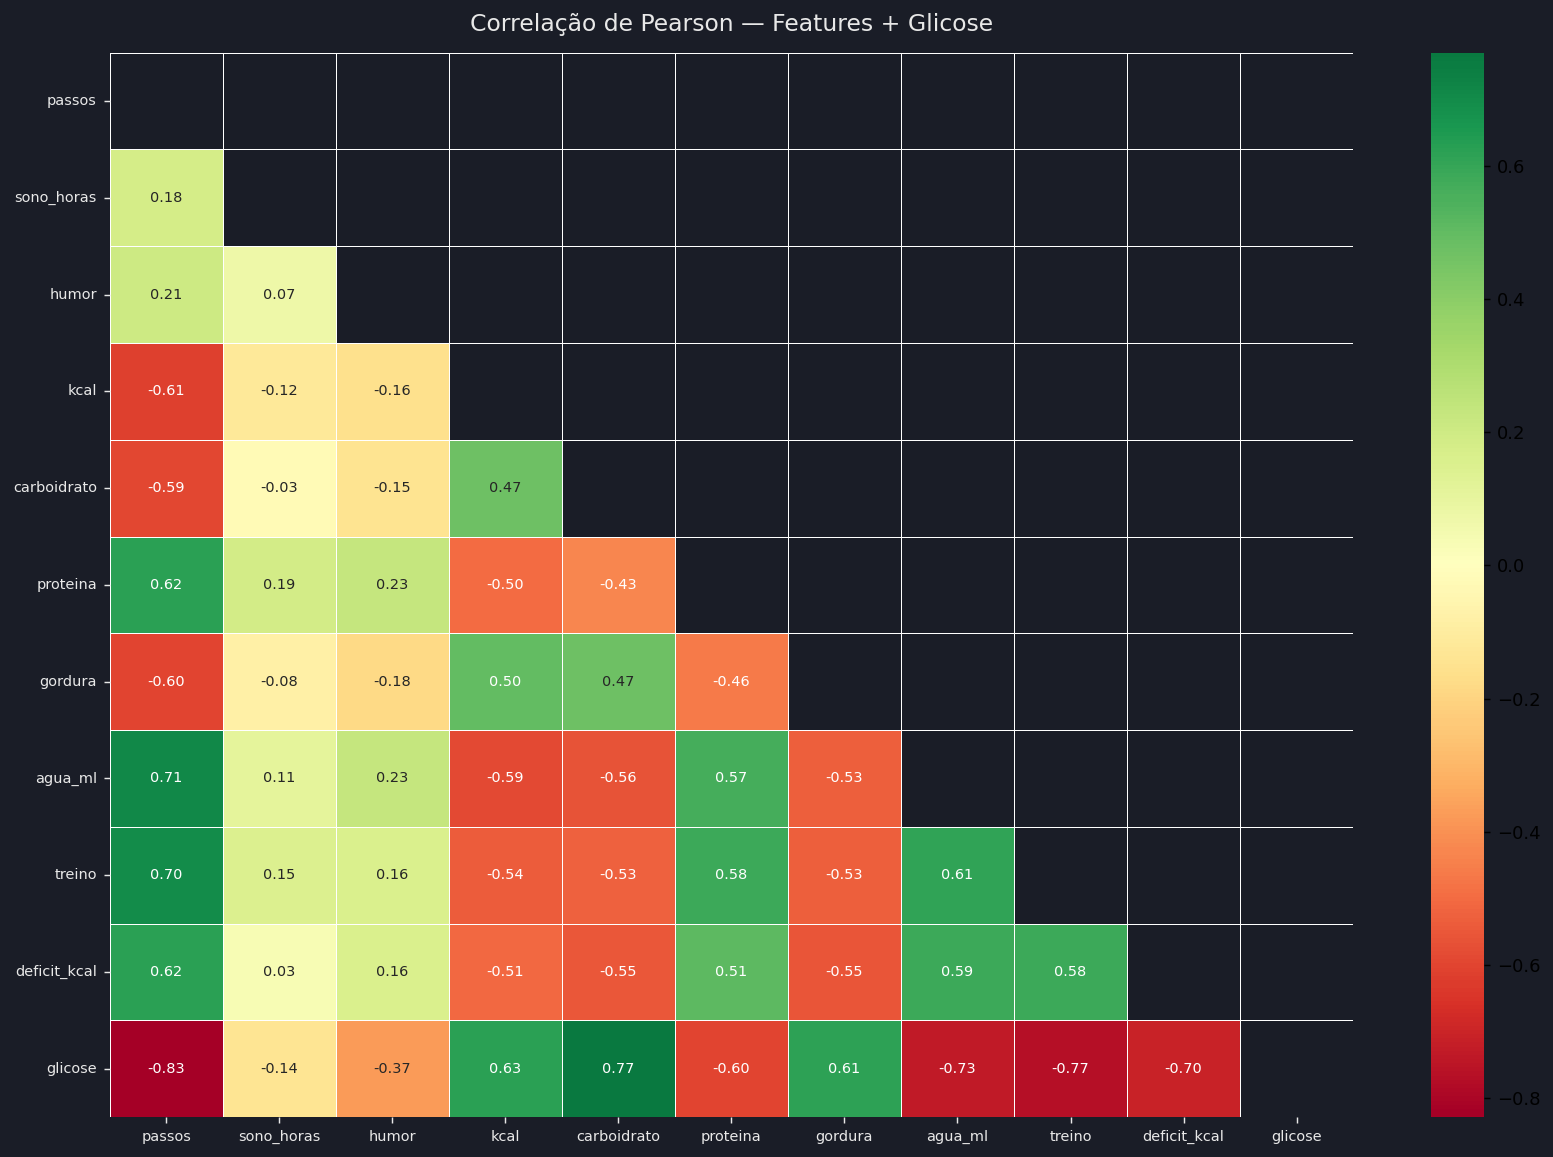


─── ETAPA 3/6 | Comparando REGRESSORES (GBT | XGBoost | RandomForest) ───
2026-04-21 10:30:17 | INFO     | RegressionComparator | Split: 400 treino | 100 teste
2026-04-21 10:30:17 | INFO     | RegressionComparator | ─── Treinando Regressão: GBT ───
2026-04-21 10:30:40 | INFO     | RegressionComparator | GBT → R²=0.8995 | RMSE=4.2221 | MAE=3.6111
2026-04-21 10:30:40 | INFO     | RegressionComparator | ─── Treinando Regressão: XGBoost ───
2026-04-21 10:30:45 | INFO     | RegressionComparator | XGBoost → R²=0.9053 | RMSE=4.0980 | MAE=3.5138
2026-04-21 10:30:45 | INFO     | RegressionComparator | ─── Treinando Regressão: RandomForest ───
2026-04-21 10:31:05 | INFO     | RegressionComparator | RandomForest → R²=0.8759 | RMSE=4.6925 | MAE=4.0583
2026-04-21 10:31:05 | INFO     | RegressionComparator | 🏆 MELHOR REGRESSÃO: XGBoost (R²=0.9053)

📋 Tabela Comparativa — Regressão:


,Modelo,R²,RMSE,MAE,CV R²,CV Std,Melhor
1,XGBoost,0.9053,4.0980,3.5138,0.8725,0.0165,✅
0,GBT,0.8995,4.2221,3.6111,0.8602,0.0165,
2,RandomForest,0.8759,4.6925,4.0583,0.8266,0.0329,



─── ETAPA 4/6 | Comparando CLASSIFICADORES (RF | XGBoost | Logística) ───
2026-04-21 10:31:05 | INFO     | ClassificationComparator | Distribuição de classes:
glicose
elevado    283
normal     180
alto        37
2026-04-21 10:31:05 | INFO     | ClassificationComparator | ─── Treinando Classificação: RandomForest ───
2026-04-21 10:31:17 | INFO     | ClassificationComparator | RandomForest → Acc=0.8600 | F1=0.8372 | AUC=0.9547
2026-04-21 10:31:17 | INFO     | ClassificationComparator | ─── Treinando Classificação: XGBoost ───
2026-04-21 10:31:23 | INFO     | ClassificationComparator | XGBoost → Acc=0.8300 | F1=0.7644 | AUC=0.9496
2026-04-21 10:31:23 | INFO     | ClassificationComparator | ─── Treinando Classificação: LogisticRegression ───
2026-04-21 10:31:25 | INFO     | ClassificationComparator | LogisticRegression → Acc=0.8600 | F1=0.8276 | AUC=0.9694
2026-04-21 10:31:25 | INFO     | ClassificationComparator | 🏆 MELHOR CLASSIFICAÇÃO: RandomForest (Acc=0.8600)

📋 Tabela Comparativa — 

,Modelo,Accuracy,F1 Macro,F1 Weighted,ROC-AUC,CV F1,CV Std,Melhor
0,RandomForest,0.86,0.8372,0.8619,0.9547,0.7468,0.0995,✅
2,LogisticRegression,0.86,0.8276,0.8634,0.9694,0.7805,0.0273,
1,XGBoost,0.83,0.7644,0.8275,0.9496,0.7280,0.0934,



─── ETAPA 5/6 | Gerando visualizações ───


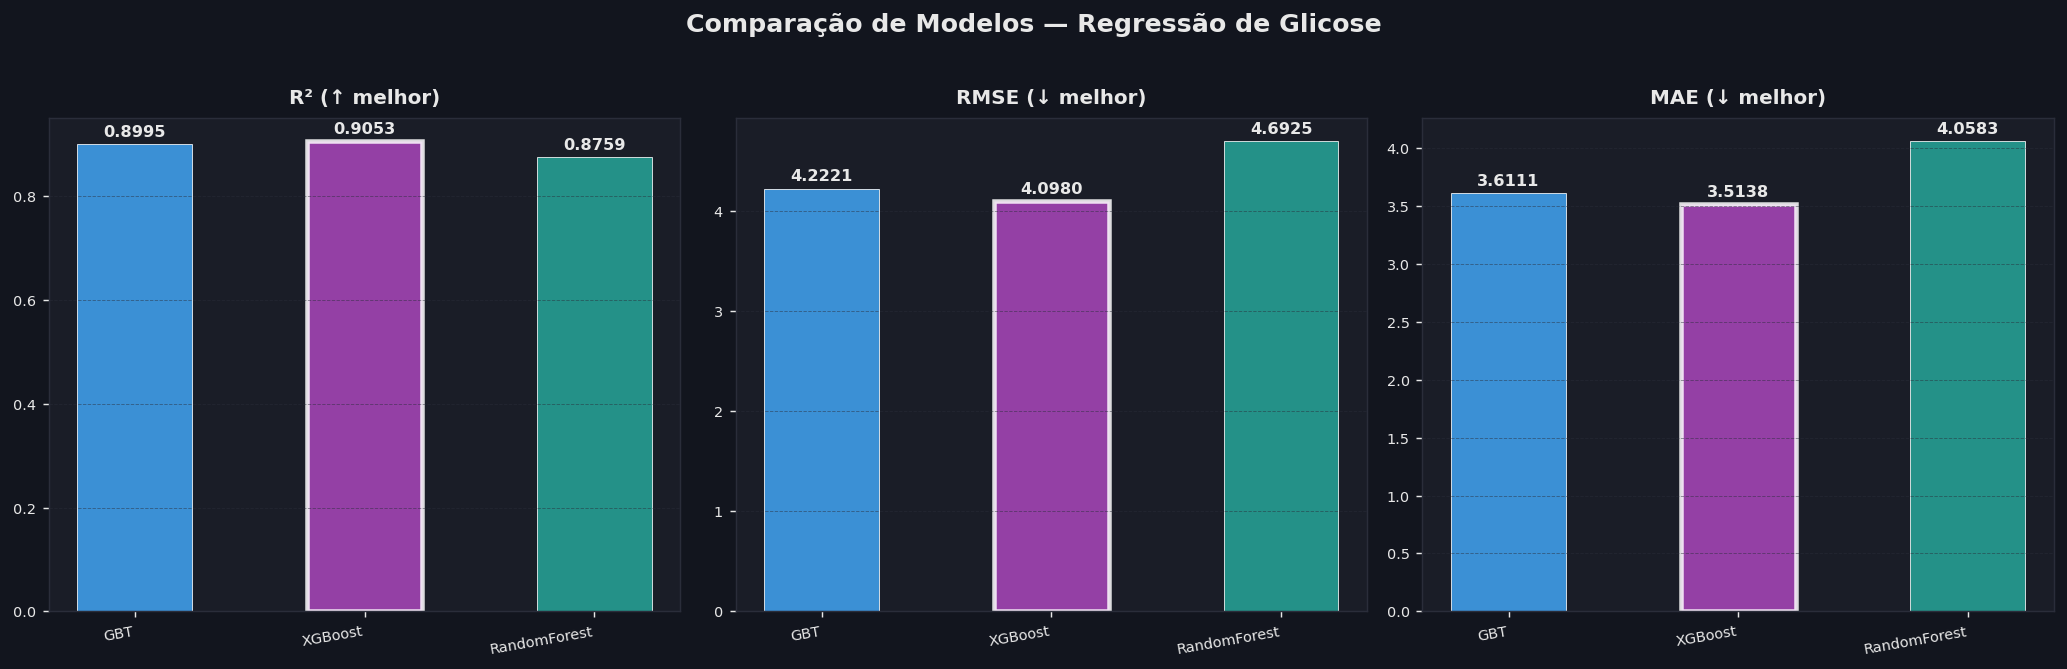

2026-04-21 10:31:26 | INFO     | ModelVisualizer | Salvo: comparacao_regressao.png


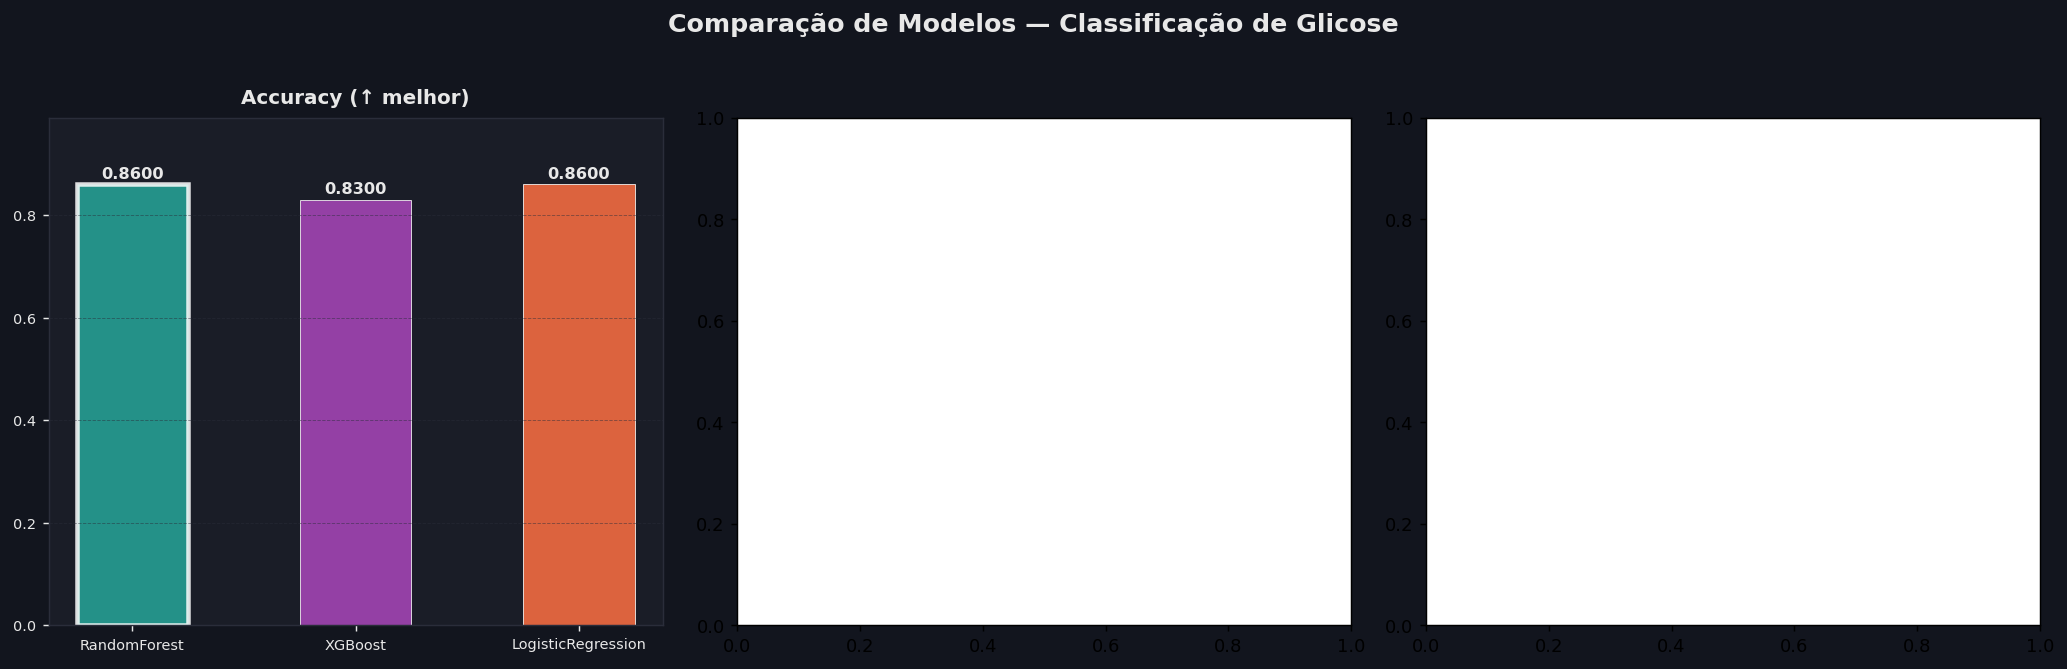

2026-04-21 10:31:27 | INFO     | ModelVisualizer | Salvo: comparacao_classificacao.png


<Figure size 640x480 with 0 Axes>

2026-04-21 10:31:27 | INFO     | ModelVisualizer | Salvo: comparacao_classificacao.png


<Figure size 640x480 with 0 Axes>

2026-04-21 10:31:27 | INFO     | ModelVisualizer | Salvo: comparacao_classificacao.png


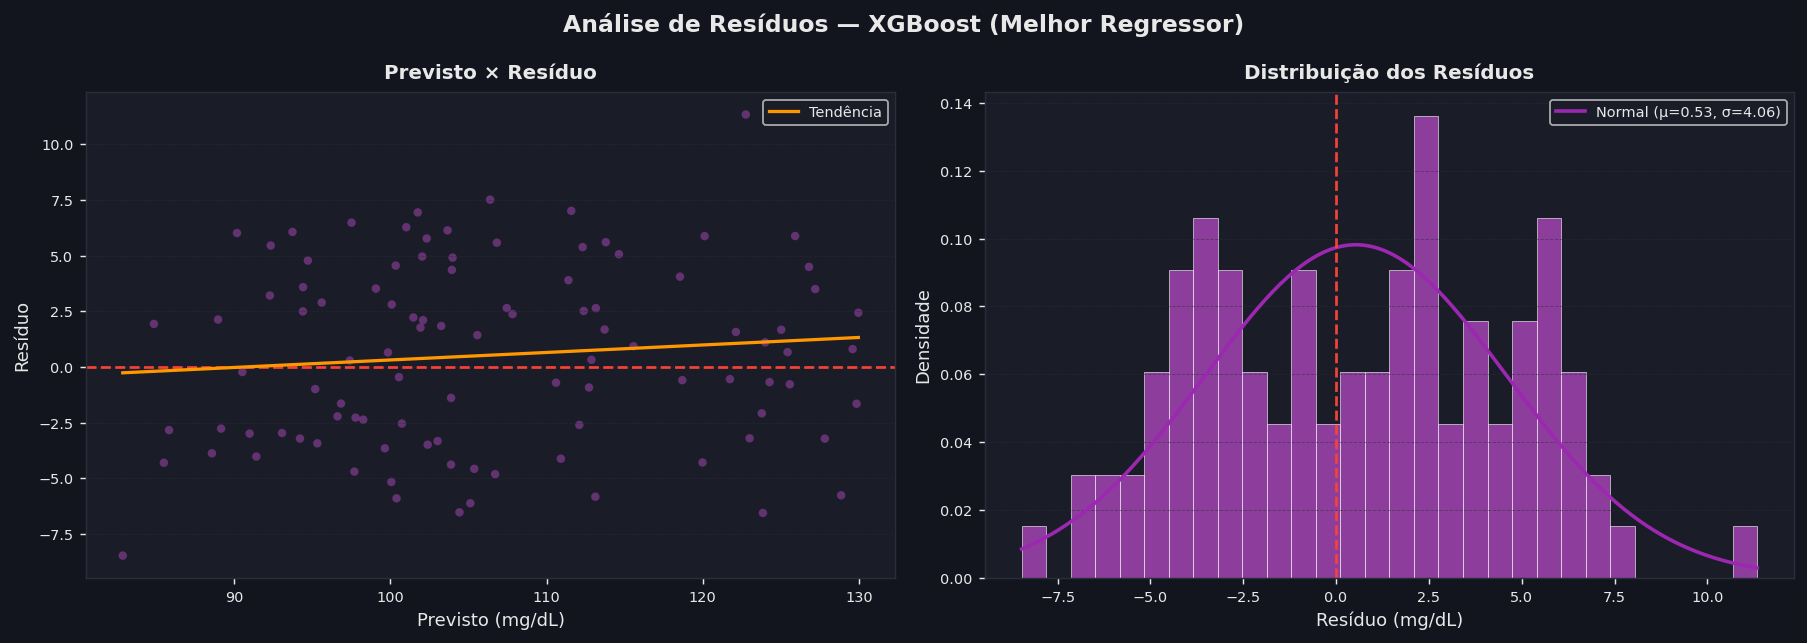

2026-04-21 10:31:29 | INFO     | ModelVisualizer | Salvo: residuos_melhor_regressor.png


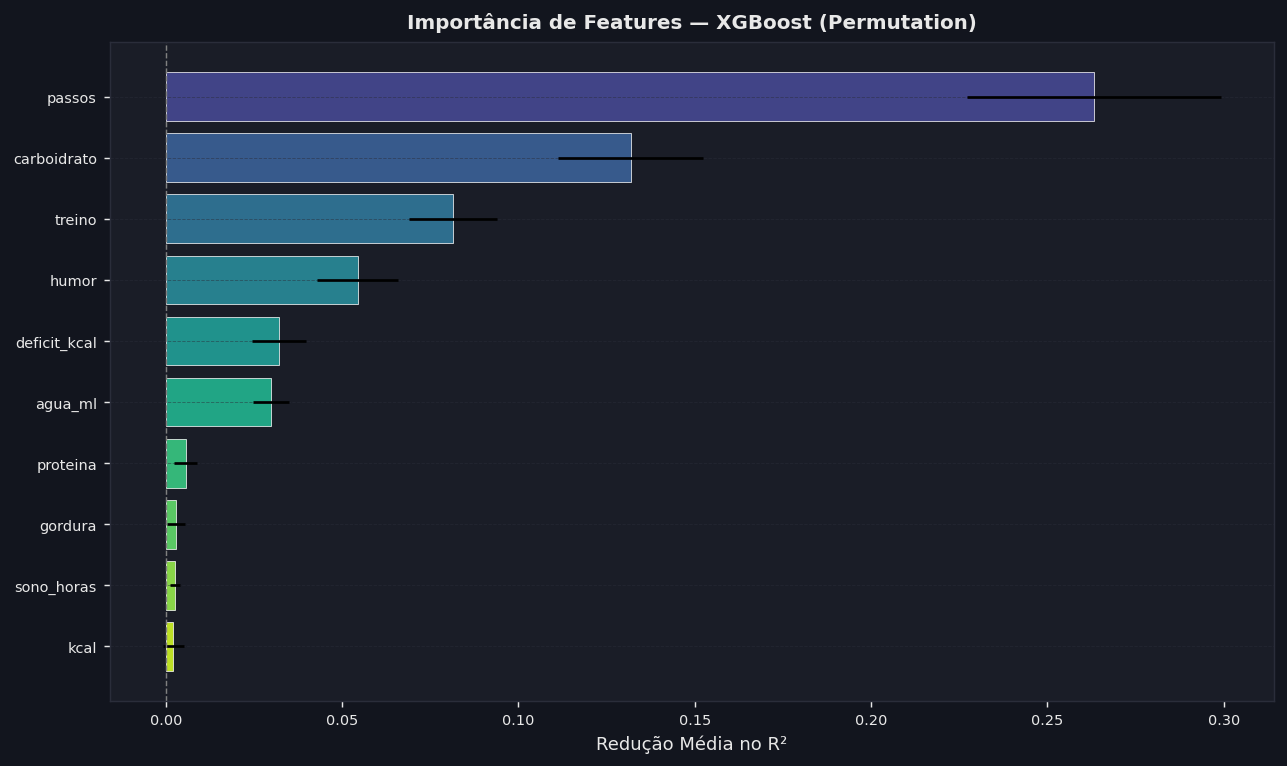

2026-04-21 10:31:30 | INFO     | ModelVisualizer | Salvo: importancia_features_regressao.png


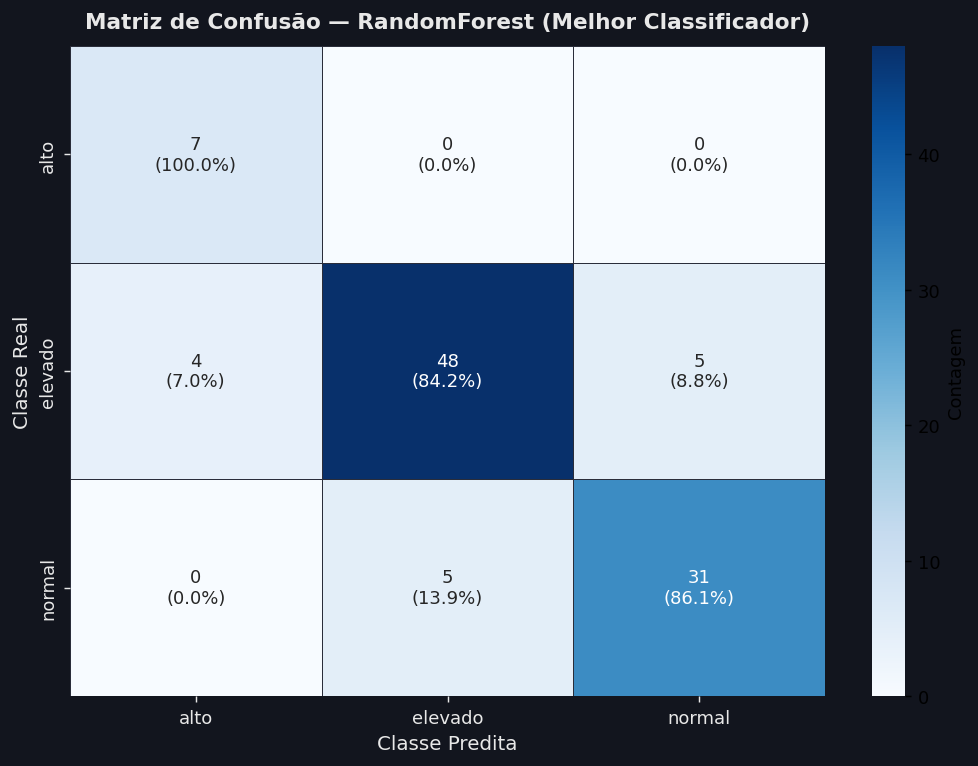

2026-04-21 10:31:30 | INFO     | ModelVisualizer | Salvo: matriz_confusao.png


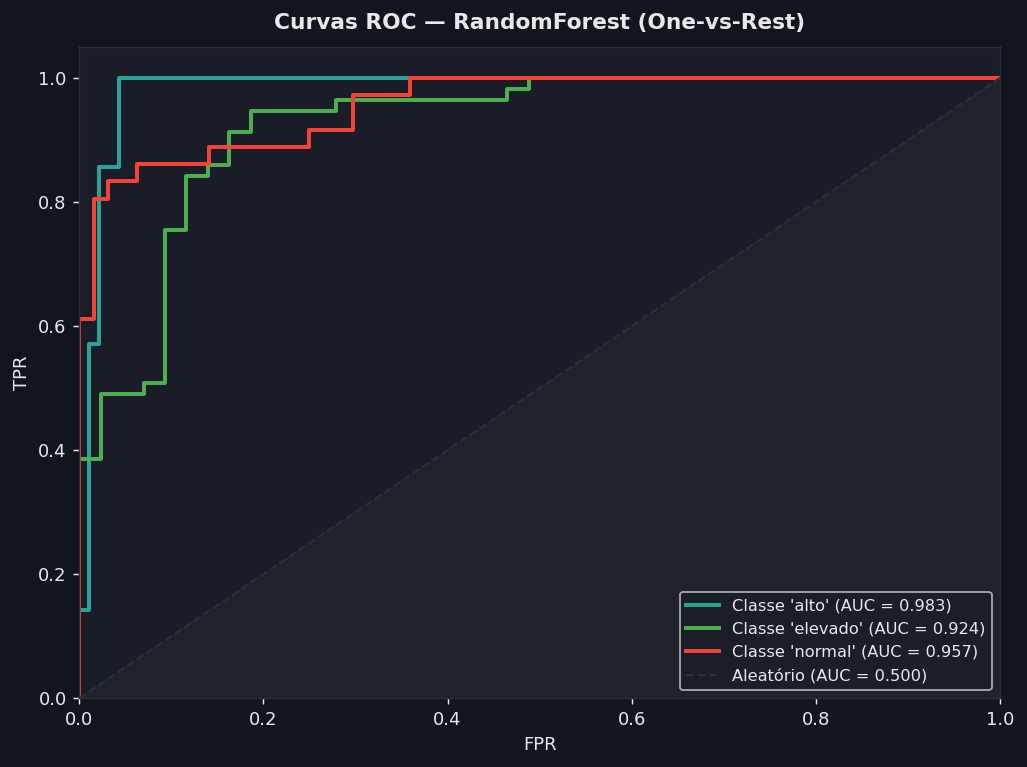

2026-04-21 10:31:31 | INFO     | ModelVisualizer | Salvo: curvas_roc.png


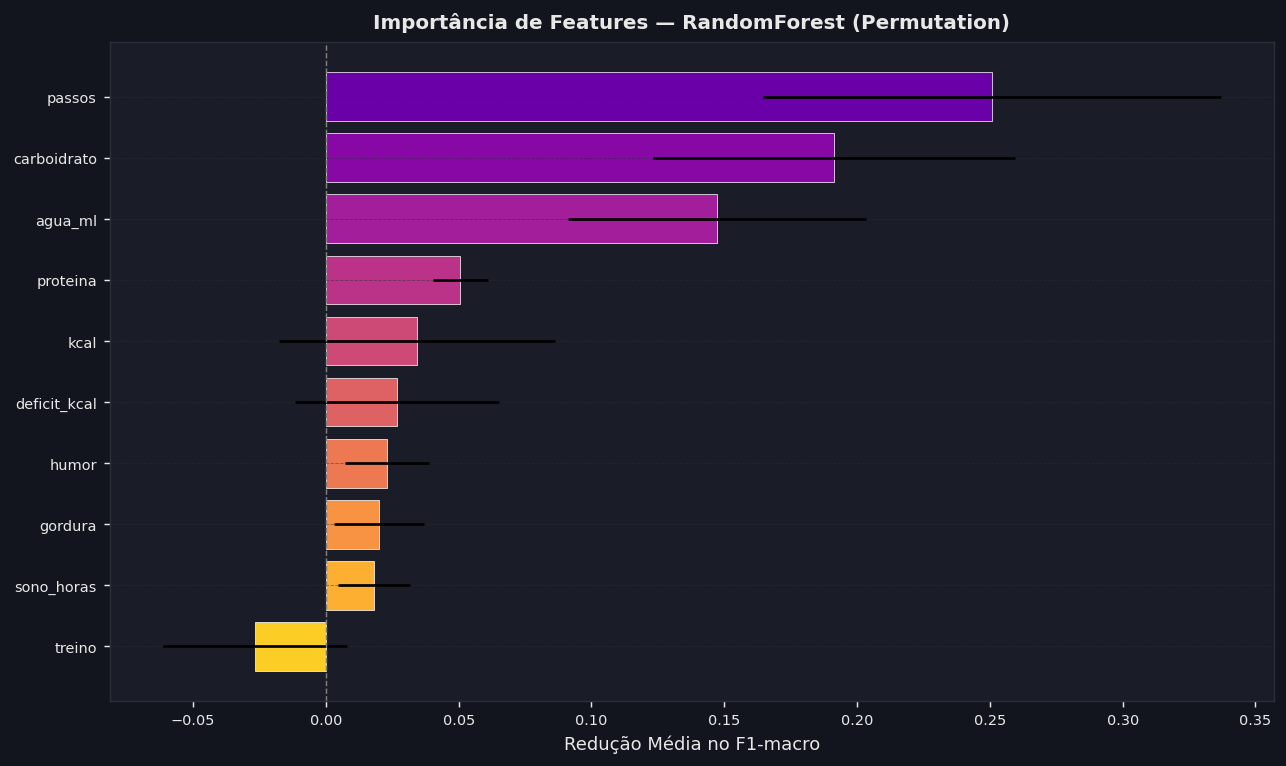

2026-04-21 10:31:34 | INFO     | ModelVisualizer | Salvo: importancia_features_classificacao.png

─── ETAPA 6/6 | Dashboard Final ───


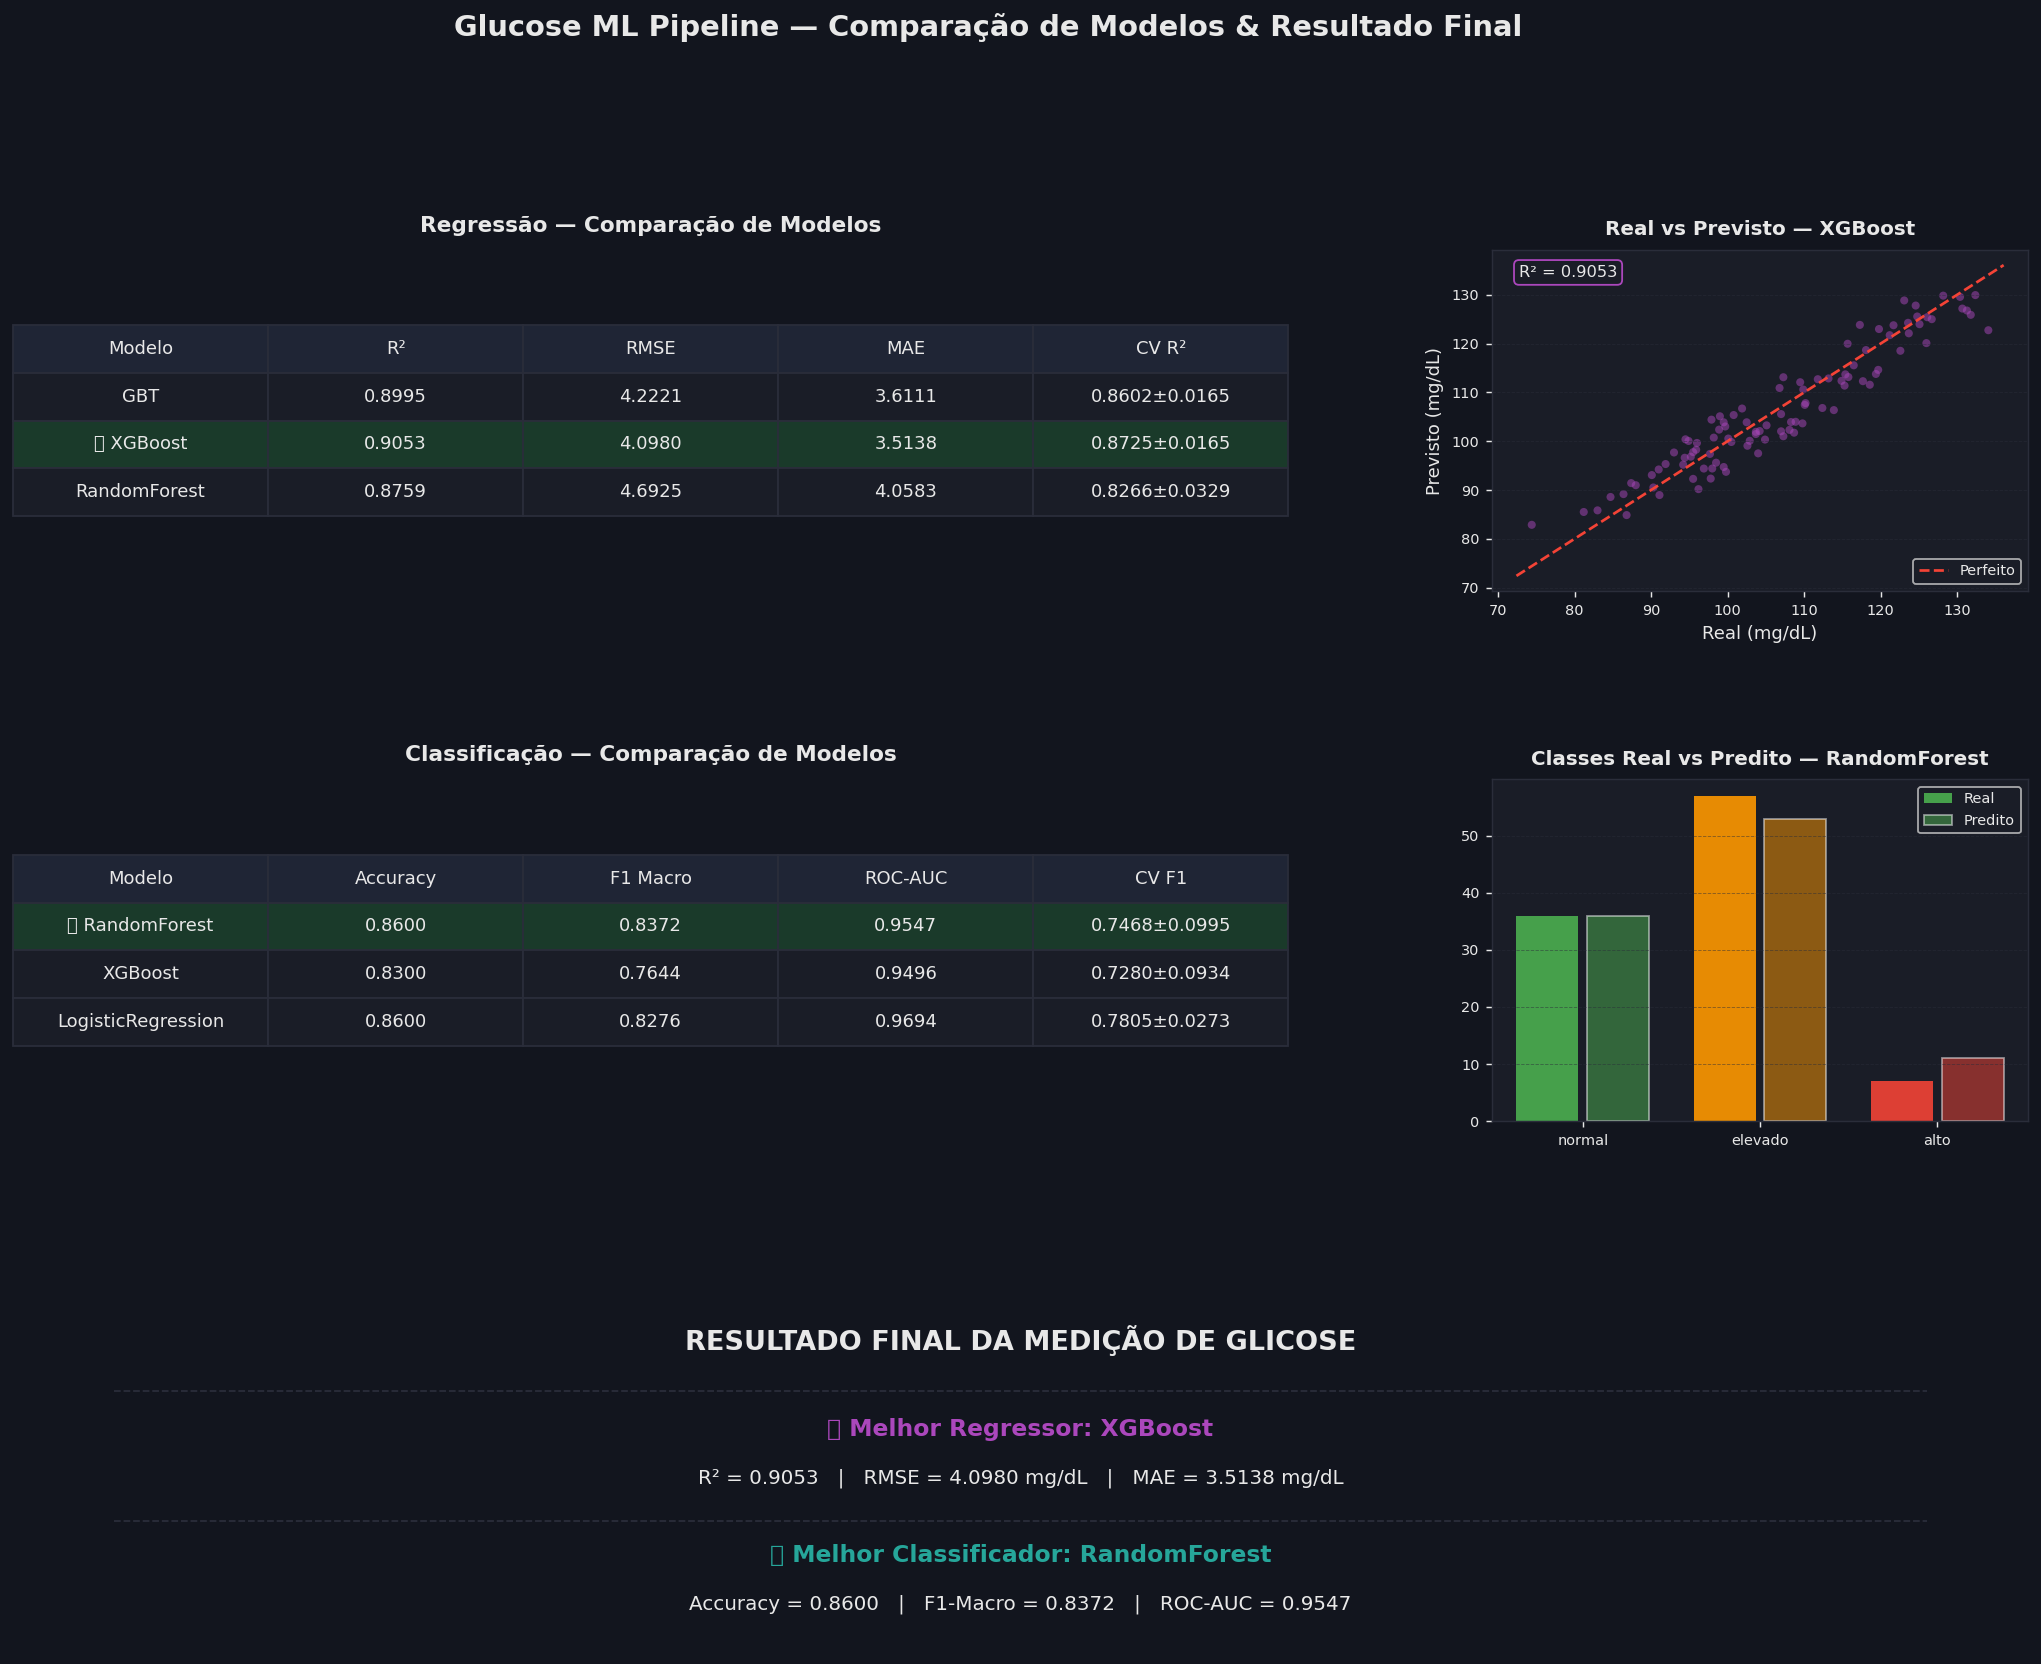

2026-04-21 10:31:36 | INFO     | ModelVisualizer | Salvo: dashboard_final.png

╔══════════════════════════════════════════════════════╗
║                 SUMÁRIO FINAL                        ║
╠══════════════════════════════════════════════════════╣
║  🏆 Melhor Regressor   → XGBoost                       ║
║     R²     = 0.9053                                  ║
║     RMSE   = 4.098                                   ║
║     MAE    = 3.5138                                  ║
╠══════════════════════════════════════════════════════╣
║  🏆 Melhor Classificador → RandomForest                ║
║     Accuracy = 0.86                                  ║
║     F1 Macro = 0.8372                                ║
║     ROC-AUC  = 0.9547                                ║
╚══════════════════════════════════════════════════════╝


In [24]:
import logging
log = logging.getLogger("main")
log.info("╔══════════════════════════════════════════════════════╗")
log.info("║   GLUCOSE ML PIPELINE — Pandas + sklearn + XGBoost  ║")
log.info("╚══════════════════════════════════════════════════════╝")

# ── 1. Carregamento ──────────────────────────────────────────────────────────
print("\n─── ETAPA 1/6 | Carregando dados ───")
loader = GlucoseDataLoader(PATH_CSV, delimiter=";")
df     = loader.load()
print(f"  Linhas: {len(df)} | Colunas: {list(df.columns)}")

# ── 2. Engenharia de features ────────────────────────────────────────────────
print("\n─── ETAPA 2/6 | Engenharia de features ───")
fe = FeatureEngineer(
    corr_threshold=0.85,
    drop_cols=["data", "classe_glicose"],
    cat_cols=["humor", "treino"],
)
X, y = fe.fit_transform(df, target_col="glicose")
fe.plot_correlation_heatmap(X, y)

# ── 3. Regressão ─────────────────────────────────────────────────────────────
print("\n─── ETAPA 3/6 | Comparando REGRESSORES (GBT | XGBoost | RandomForest) ───")
reg_comp = RegressionComparator(n_iter=15)
reg_comp.fit(X, y)

print("\n📋 Tabela Comparativa — Regressão:")
display(reg_comp.summary())

# ── 4. Classificação ─────────────────────────────────────────────────────────
print("\n─── ETAPA 4/6 | Comparando CLASSIFICADORES (RF | XGBoost | Logística) ───")
clf_comp = ClassificationComparator(n_iter=12)
clf_comp.fit(X, y)

print("\n📋 Tabela Comparativa — Classificação:")
display(clf_comp.summary())

# ── 5. Visualizações ─────────────────────────────────────────────────────────
print("\n─── ETAPA 5/6 | Gerando visualizações ───")
viz = ModelVisualizer()
viz.plot_regression_comparison(reg_comp)
viz.plot_classification_comparison(clf_comp)
viz.plot_residuals(reg_comp)
viz.plot_feature_importance_regression(reg_comp)
viz.plot_confusion_matrix(clf_comp)
viz.plot_roc_curves(clf_comp)
viz.plot_feature_importance_classification(clf_comp)

# ── 6. Dashboard Final ───────────────────────────────────────────────────────
print("\n─── ETAPA 6/6 | Dashboard Final ───")
viz.plot_final_dashboard(reg_comp, clf_comp)

# ── Sumário ──────────────────────────────────────────────────────────────────
best_r = reg_comp.best_name_
best_c = clf_comp.best_name_
rr     = reg_comp.results_[best_r]
cr     = clf_comp.results_[best_c]

print("\n╔══════════════════════════════════════════════════════╗")
print("║                 SUMÁRIO FINAL                        ║")
print("╠══════════════════════════════════════════════════════╣")
print(f"║  🏆 Melhor Regressor   → {best_r:<30}║")
print(f"║     R²     = {rr['R²']:<40}║")
print(f"║     RMSE   = {rr['RMSE']:<40}║")
print(f"║     MAE    = {rr['MAE']:<40}║")
print("╠══════════════════════════════════════════════════════╣")
print(f"║  🏆 Melhor Classificador → {best_c:<28}║")
print(f"║     Accuracy = {cr['Accuracy']:<38}║")
print(f"║     F1 Macro = {cr['F1 Macro']:<38}║")
print(f"║     ROC-AUC  = {cr['ROC-AUC']!s:<38}║")
print("╚══════════════════════════════════════════════════════╝")
